# Testing out dustapprox

[dustapprox docs](https://mfouesneau.github.io/dustapprox/examples.html)

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import pyphot
from astropy import constants

from dustapprox.extinction import evaluate_extinction_model
from dustapprox.tools import generate_model
from dustapprox.models import PrecomputedModel
from dustapprox.models.polynomial import PolynomialModel

from gaianir_open_clusters.data import fetch_kurucz_models
from gaianir_open_clusters.config import DATA_DIRECTORY


import os
os.environ['OCELOT_DATA'] = (DATA_DIRECTORY / "ocelot_data").as_posix()

from ocelot.simulate.photometry import load_isochrone

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
# fetch_kurucz_models()

## Plotting extinction models in nm

(because i am bad at wavenumber)

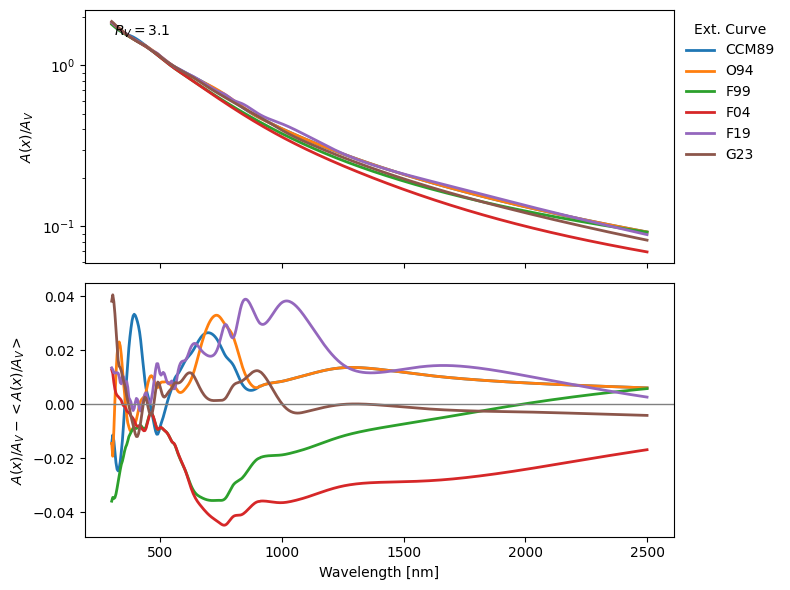

In [3]:
#define the wave numbers
x = np.linspace(300, 2500, num=500)
λ = x * u.nm

curves = 'CCM89', 'O94', 'F99', 'F04', 'F19', 'G23'
R0 = 3.1

curve_data = {}
_, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for name in curves:
    values = evaluate_extinction_model(name, λ, A0=1.0, R0=R0)
    curve_data[name] = values
    axes[0].plot(x, values, label=f'{name:s}', lw=2)

mean_curve = np.nanmean(list(curve_data.values()), axis=0)
for name, values in curve_data.items():
    diff = values - mean_curve
    axes[1].plot(x, diff, label=f'{name:s}', lw=2)

axes[0].set_ylabel(r'$A(x)/A_V$')
axes[0].legend(loc='upper left', frameon=False, title=r'Ext. Curve', bbox_to_anchor=(1.0, 1.0))
axes[0].text(0.05, 0.9, rf'$R_V={R0:.1f}$', transform=axes[0].transAxes)
axes[1].set_xlabel(r'Wavelength [nm]')
axes[1].set_ylabel(r'$A(x)/A_V - <A(x)/A_V>$')
axes[1].axhline(0.0, color='0.5', ls='-', lw=1)
# axes[0].set_ylim(-0.2, 5.2)
# axes[1].set_ylim(-0.42, 0.19)
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()

## Trying to generate a model for one passband

In [4]:
model_pattern = (DATA_DIRECTORY / "models/Kurucz2003all/*.fl.dat.txt").as_posix()

points = np.linspace(0., 10, num=11)
# points[0] = 0.001

result = generate_model.generate_grid(
    model_pattern,
    "./dust.ecsv",
    ['GAIA/GAIA3.G', 'GAIA/GAIA3.Gbp', 'GAIA/GAIA3.Grp'],
    atmosphere_name="Kurucz (ODFNEW/NOVER 2003)",
    extinction_curve="G23",
    A0=points,
    R0=np.asarray([3.1]),
)

Computing photometric grid
   - Existing grid from dust.ecsv. Skipping computation and reloading from file.


In [5]:
features = "teff A0 R0".split()
model_output_path = "model.ecsv"

models = generate_model.train_polynomial_model(result, model_output_path, features, degree=3)
generate_model.export_trained_model_to_ecsv(model_output_path, models)

Training polynomial models for features: teff, A0, R0


fit: 100%|██████████| 3/3 [00:00<00:00,  7.11it/s]

Exporting grid to model.ecsv. done.


In [6]:
models

[PolynomialModel: GAIA_GAIA3.G 
    from: A0, R0, teffnorm   polynomial degree: 3,
 PolynomialModel: GAIA_GAIA3.Gbp 
    from: A0, R0, teffnorm   polynomial degree: 3,
 PolynomialModel: GAIA_GAIA3.Grp 
    from: A0, R0, teffnorm   polynomial degree: 3]

## Using the photometric grid for photometry too

### Working out what's going on

[None]

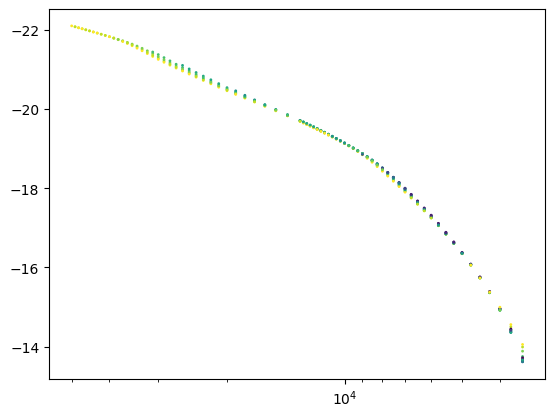

In [125]:
fig, ax = plt.subplots()

good = result.query("feh==0.0 and alpha==0.0 and A0==0.0 and passband=='GAIA_GAIA3.G'").reset_index(
    drop=True
)

# distance_correction =

ax.scatter(good["teff"], good["mag"], s=1, c=good['logg'])
ax.invert_xaxis()
ax.invert_yaxis()
ax.set(xscale="log")

Those numbers look far too high. It turns out that Kurucz models are **surface photometry**, and need some adjustment...

In [34]:
models[0].predict(good)

array([0.89208155, 0.92516836, 0.8883929 , 0.87244472, 0.87661383,
       0.9346974 , 0.79419165, 0.78785834, 1.00953036, 0.95826655,
       0.92282005, 0.95158686, 0.95989675, 0.93114566, 0.82368913,
       0.80641991, 0.95769334, 0.94779845, 0.94648409, 0.96065709,
       0.9562357 , 0.91182362, 0.9202265 , 0.74669453, 0.96803933,
       0.94452764, 0.82916542, 0.84477514, 0.93575104, 0.93173788,
       0.85918794, 0.85451413, 0.92407137, 0.9024556 , 0.90568804,
       0.76102855, 0.76796351, 0.95545859, 0.92773307, 0.78137689,
       0.80037833, 0.94892792, 0.9938609 , 0.95090469, 0.8845864 ,
       0.89565387, 0.93219764, 0.95974504, 0.88066055, 0.86815171,
       0.81231789, 0.8180738 , 0.92409838, 0.92687641, 0.93788017,
       0.9236824 , 0.73929243, 0.83970691, 0.83450418, 0.94118923,
       0.91753025, 0.92909857, 0.9147298 , 0.94164614, 0.77474578,
       0.7539394 , 0.95819624, 0.92541629, 0.84971037, 0.86373329,
       0.94005334, 0.9605742 , 0.9088102 , 0.98006287, 0.95374

In [ ]:
lib = PrecomputedModel()
r = lib.find(passband="Gaia")[0]
default_model = lib.load_model(r)
default_model[0].predict(good)  # * good['A0']

array([0.87661373, 0.92983318, 0.87312359, 0.85818271, 0.86206725,
       0.93854221, 0.78710841, 0.78146503, 0.96962688, 0.95257701,
       0.90643461, 0.93705491, 0.94862437, 0.92770284, 0.81357163,
       0.79804103, 0.94033693, 0.94766989, 0.93117277, 0.95069684,
       0.95199962, 0.895583  , 0.9038512 , 0.74505446, 0.94591671,
       0.94560243, 0.81852146, 0.83270574, 0.92955358, 0.93614448,
       0.84591596, 0.8416189 , 0.92826499, 0.88651404, 0.88962789,
       0.75768464, 0.76381303, 0.94187589, 0.92660314, 0.77570209,
       0.79263337, 0.93579814, 0.9604892 , 0.94947357, 0.86953656,
       0.88000809, 0.91593511, 0.95260067, 0.86585149, 0.85419674,
       0.80333254, 0.80850903, 0.92636691, 0.93171748, 0.9409661 ,
       0.9270854 , 0.73855041, 0.82808739, 0.82335967, 0.94334367,
       0.90118222, 0.93384541, 0.89842653, 0.93222785, 0.76981847,
       0.75143216, 0.94570822, 0.92618199, 0.83721587, 0.8501082 ,
       0.924157  , 0.95199811, 0.8926505 , 0.95260997, 0.95094

AHHHHH. So, dustapprox predicts $A_x / A_0$ - so you have to multiply by $A_0$ to get extinction in that band.

### Getting photometry

So, I think that simply multiplying by the radius can get me from one to another...

In [120]:
class Params:
    log_age = np.log10(1e8)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["teff"] = 10 ** iso["logTe"]
iso["lum"] = 10 ** iso["logL"] * constants.L_sun.value
iso["radius"] = np.sqrt(
    iso["lum"] / (4 * np.pi * constants.sigma_sb.value * iso["teff"] ** 4)
)

iso

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag,teff,lum,radius
0,0.01471,0.0,7.99007,0.090000,1.081690,0.090,-2.745,3.4030,4.702,0,...,0.006496,-1.0,0.01476,11.634,13.677,16.450,12.201,2529.297996,6.886078e+23,1.536651e+08
1,0.01471,0.0,7.99007,0.094077,1.119634,0.094,-2.713,3.4076,4.707,0,...,0.006496,-1.0,0.01476,11.552,13.596,16.369,12.120,2556.230427,7.412623e+23,1.560900e+08
2,0.01471,0.0,7.99007,0.100000,1.171106,0.100,-2.665,3.4143,4.712,0,...,0.006496,-1.0,0.01476,11.433,13.476,16.251,12.000,2595.971977,8.278887e+23,1.599467e+08
3,0.01471,0.0,7.99007,0.102113,1.188520,0.102,-2.651,3.4162,4.714,0,...,0.006496,-1.0,0.01476,11.396,13.430,16.194,11.956,2607.354004,8.550114e+23,1.611295e+08
4,0.01471,0.0,7.99007,0.112812,1.270011,0.113,-2.576,3.4259,4.722,0,...,0.006496,-1.0,0.01476,11.211,13.130,15.746,11.682,2666.244668,1.016183e+24,1.679868e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,0.01471,0.0,7.99007,5.356968,2.615771,5.355,3.898,3.5724,0.511,7,...,0.005729,-1.0,0.01487,-4.974,-4.273,-3.255,-5.269,3735.940923,3.026718e+30,1.476642e+11
458,0.01471,0.0,7.99007,5.355704,2.615765,5.355,3.816,3.5805,0.625,7,...,0.005731,-1.0,0.01486,-4.771,-4.159,-3.219,-5.116,3806.273576,2.505947e+30,1.294420e+11
459,0.01471,0.0,7.99007,5.354951,2.615762,5.355,3.775,3.5845,0.682,7,...,0.005731,-1.0,0.01487,-4.667,-4.093,-3.182,-5.033,3841.492592,2.280195e+30,1.212202e+11
460,0.01471,0.0,7.99007,5.357528,2.615773,5.355,3.938,3.5683,0.454,7,...,0.005726,-1.0,0.01489,-5.075,-4.324,-3.259,-5.342,3700.837363,3.318730e+30,1.575706e+11


In [52]:
solar_values = iso.loc[iso['Mass'] == 1.0]
solar_values

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag,teff,lum,radius
48,0.01471,0.0,9.65004,1.0,2.472915,1.0,0.039,3.7694,4.428,1,...,0.005814,-1.0,0.01326,4.672,4.548,4.865,4.064,5880.306995,4.187665e+26,7.010922e+08


In [74]:
result.query("teff==10000 and alpha==0.0 and feh==-0.5 and logg==4.0 and A0==0").sort_values("teff")

,teff,logg,feh,alpha,passband,mag0,mag,A0,R0,Ax
250998,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.G,-19.106995,-19.106995,0.0,3.1,0.0
251009,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.Gbp,-19.647036,-19.647036,0.0,3.1,0.0
251020,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.Grp,-18.350227,-18.350227,0.0,3.1,0.0


In [13]:
lib = pyphot.get_library()
filter = lib.load_filters(["Gaia_G"])[0]

Let's try with a few numbers just read off to check I understand this correctly:

In [14]:
# For the sun
-17.05197 -5 * np.log10((7e8 / (10 * u.pc).to(u.m).value)) - filter.Vega_zero_mag

np.float64(4.661668637976323)

In [22]:
# For vega
-19.106995 - 5 * np.log10((2.726 * constants.R_sun / (7.68 * u.pc).to(u.m)).value) - filter.Vega_zero_mag

np.float64(-0.8864823102014725)

So! the equation seems to be

$$
M = m_\text{surface} - 5 \log_{10} \left(\frac{R}{10\text{ pc}} \right) - m_\text{0}
$$

### A photometry helper

In [16]:
lib = pyphot.get_library()

In [17]:
lib.find("Gaia")

['GaiaDR2_BP',
 'GaiaDR2_G',
 'GaiaDR2_RP',
 'GaiaDR2_weiler_BPbright',
 'GaiaDR2_weiler_BPfaint',
 'GaiaDR2_weiler_G',
 'GaiaDR2_weiler_RP',
 'GaiaDR2v2_BP',
 'GaiaDR2v2_G',
 'GaiaDR2v2_RP',
 'Gaia_BP',
 'Gaia_G',
 'Gaia_MAW_BP_bright',
 'Gaia_MAW_BP_faint',
 'Gaia_MAW_G',
 'Gaia_MAW_RP',
 'Gaia_RP',
 'Gaia_rvs']

In [110]:
PHOTOMETRIC_GRID = result.query("A0==0.0 and alpha==0.0 and R0==3.1").reset_index(
    drop=True
)

bands = PHOTOMETRIC_GRID["passband"].unique()
bands_short = [band.split(".")[1] for band in bands]

for band, band_long in zip(bands_short, bands):
    # Grab the Gaia filter
    filter_name = band
    if len(filter_name) > 1:
        filter_name = filter_name[1:]
    filter = lib.load_filters([f"Gaia_{filter_name.upper()}"])[0]

    # Copy photometry just to the valid set
    valid = PHOTOMETRIC_GRID["passband"] == band_long
    PHOTOMETRIC_GRID.loc[valid, band] = (
        PHOTOMETRIC_GRID.loc[valid, "mag0"] - filter.Vega_zero_mag
    )

mags = {band: pd.NamedAgg(band, "first") for band in bands_short}

PHOTOMETRIC_GRID = (
    PHOTOMETRIC_GRID.groupby(["teff", "logg", "feh"]).aggregate(**mags).reset_index()
)

PHOTOMETRIC_GRID

,teff,logg,feh,G,Gbp,Grp
0,3500.0,0.0,-2.5,-35.319389,-34.018051,-36.439766
1,3500.0,0.0,-2.0,-35.366230,-34.148735,-36.457401
2,3500.0,0.0,-1.5,-35.385765,-34.226326,-36.457840
3,3500.0,0.0,-1.0,-35.369240,-34.228119,-36.439701
4,3500.0,0.0,-0.5,-35.316803,-34.137615,-36.409508
...,...,...,...,...,...,...
3803,50000.0,5.0,-1.0,-43.559956,-43.729027,-43.241341
3804,50000.0,5.0,-0.5,-43.578644,-43.748714,-43.257195
3805,50000.0,5.0,0.0,-43.602486,-43.774044,-43.276642
3806,50000.0,5.0,0.2,-43.614670,-43.787056,-43.286263


In [140]:
from scipy.interpolate import NearestNDInterpolator, LinearNDInterpolator, interp1d

In [157]:
x = PHOTOMETRIC_GRID[["teff", "logg", "feh"]].to_numpy()
y = PHOTOMETRIC_GRID["G"]
y_big = PHOTOMETRIC_GRID[["G", "Gbp", "Grp"]]

linear_int = LinearNDInterpolator(x, y_big)
# nearest_int = NearestNDInterpolator(x, y_big, rescale=True)

In [161]:
min_log_g = (
    PHOTOMETRIC_GRID.groupby("teff")
    .aggregate(logg=pd.NamedAgg("logg", "min"))
    .reset_index()
)
min_log_g_interpolator = interp1d(
    min_log_g["teff"],
    min_log_g["logg"],
    bounds_error=False,
    fill_value=(min_log_g["logg"].min(), min_log_g["logg"].max()),
)

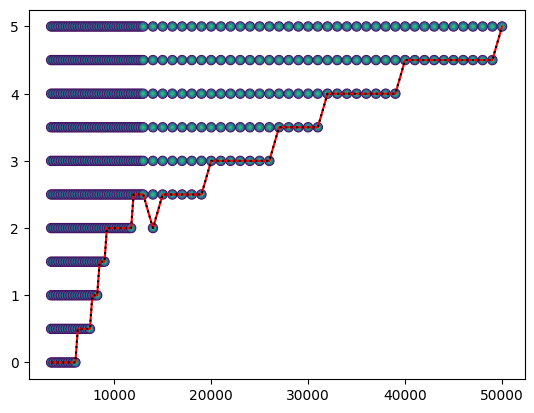

In [156]:
plt.scatter(
    PHOTOMETRIC_GRID["teff"],
    PHOTOMETRIC_GRID["logg"],
    c=PHOTOMETRIC_GRID["feh"],
    s=20 * (-PHOTOMETRIC_GRID["feh"] - PHOTOMETRIC_GRID["feh"].max() + 0.1),
)
plt.plot(min_log_g['teff'], min_log_g['logg'], 'r-')
plt.plot(min_log_g['teff'], min_log_g_interpolator(min_log_g['teff']), 'k:')


In [127]:
values = linear_int(iso[['teff', 'logg', 'MH']].to_numpy())

bad_values = np.any(np.isnan(values), axis=1)
bad_values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False,  True,
        True, False,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False,  True, False,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
       False,  True,

In [ ]:
np.asarray(((50000, 5, 0), (70000, 0, 0))).shape

(2, 3)

In [89]:
nearest_int(((50000, 5, 0), (70000, 0, 0)))

ValueError: number of dimensions in xi does not match x

In [228]:
MIN_TEFF = PHOTOMETRIC_GRID["teff"].min()
MAX_TEFF = PHOTOMETRIC_GRID["teff"].max()
MAX_LOG_G = PHOTOMETRIC_GRID["logg"].max()


def get_photometry(data):
    # Lookup the values of the photometry
    values = data[["teff", "logg", "MH"]].copy()
    values["teff"] = np.clip(values["teff"], MIN_TEFF, MAX_TEFF)
    values["logg"] = np.clip(
        values["logg"], min_log_g_interpolator(values["teff"]), MAX_LOG_G
    )
    phot = linear_int(values.to_numpy())
    if np.any(np.isnan(phot)):
        raise RuntimeError("NaN photometry generated (somehow).")

    # Apply radius correction
    radii = 5 * np.log10(
        (data["radius"].to_numpy() / (10 * u.pc).to(u.m)).value
    ).reshape(-1, 1)

    # Apply temperature correction (sort of, lmao)
    temperature_offset = 4 * np.log10(values["teff"] / data["teff"]).to_numpy().reshape(
        -1, 1
    )

    return phot - radii + temperature_offset

In [229]:
iso_good = iso.query("label < 7")

g, bp, rp = get_photometry(iso_good).T

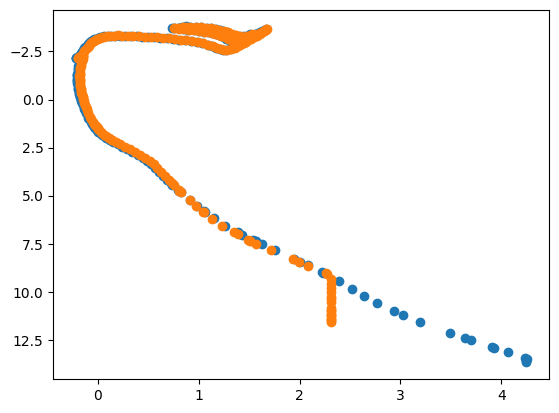

In [230]:
plt.scatter(iso_good['G_BPmag'] - iso_good['G_RPmag'], iso_good['Gmag'])
plt.scatter(bp - rp, g)
plt.gca().invert_yaxis()

ah fuck it sucks for M dwarfs

everyone hates M dwarfs

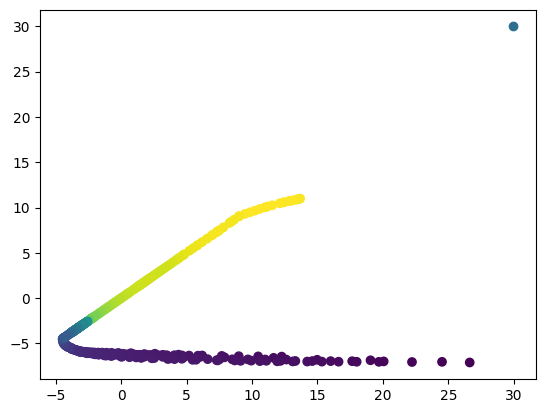

In [173]:
plt.scatter(iso['Gmag'], g, c=iso['logg'])